# Part II of WS4
# Deep learning: representation learning

## Context

Imagine that you installed accelerometers on a pedestrian bridge and collected thousands of hours of vibration data. The sensors work perfectly—but now you face another problem: no engineer can inspect every signal individually.

Each record mixes several causes:

- **environment:** temperature changes the bridge stiffness;
- **operation:** cyclists, runners, and other loads excite it differently;
- **structure:** damage may introduce a local change in stiffness.

We would like to replace every long signal with a compact representation while retaining the information that matters.

> **Can a neural network recover meaningful factors from vibration data without being told the temperature, load, or damage state?**
## Dataset

A real monitoring campaign rarely tells us the true temperature effect, applied force, or exact moment when damage begins. That makes it difficult to judge whether a learned representation is meaningful.

We therefore use [DynaResp](https://github.com/YacineBelHadj/DynaResp) to build a controlled virtual campaign. The simulation is not the final application; it is a laboratory in which the hidden causes are known. During training we hide those causes from the neural network, then reveal them afterward to interpret what it learned.

## Workshop flow

```text
simulate the campaign
→ inspect responses and modal frequencies
→ build a PCA damage benchmark
→ train a convolutional autoencoder
→ inspect its representation
→ detect novelty using latent distance and reconstruction error
```

In [1]:
# 0. Setup and configuration 
from pathlib import Path

import dynaresp as dr
import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from lightning.pytorch.loggers import CSVLogger
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Subset

plt.style.use("seaborn-v0_8-whitegrid")
L.seed_everything(42, workers=True)

/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42


42

## 1. Generate a monitoring campaign

For every experiment, think of the measured response as

\[
\text{vibration}=f(\text{environment},\text{operation},\text{structural health}).
\]

Temperature changes Young's modulus globally. A randomly selected load changes how the beam is excited. The bridge remains healthy until a local 20% stiffness reduction is introduced near the end of the test period.

The campaign contains **4,000 experiments**:

- 3,000 healthy training records;
- 200 healthy validation records;
- 400 healthy test records;
- 400 damaged test records.

Each experiment contains two accelerometers and 4,000 time samples.

In [2]:
N_TRAIN = 3000
N_VAL = 200
N_TEST_HEALTHY = 400
N_TEST_DAMAGE = 400
N_SAMPLE = N_TRAIN + N_VAL + N_TEST_HEALTHY + N_TEST_DAMAGE

damage_start = N_TRAIN + N_VAL + N_TEST_HEALTHY
monitoring_index = np.arange(N_SAMPLE)

In [3]:
def stiffness_scale(temperature, reference=20, alpha=2e-2):
    return 1 - alpha * (temperature - reference)


temperature_profile = (
    20
    + 10 * np.sin(2 * np.pi * 60 * monitoring_index / N_SAMPLE)
    + 7 * np.sin(2 * np.pi * 7 * monitoring_index / N_SAMPLE)
)

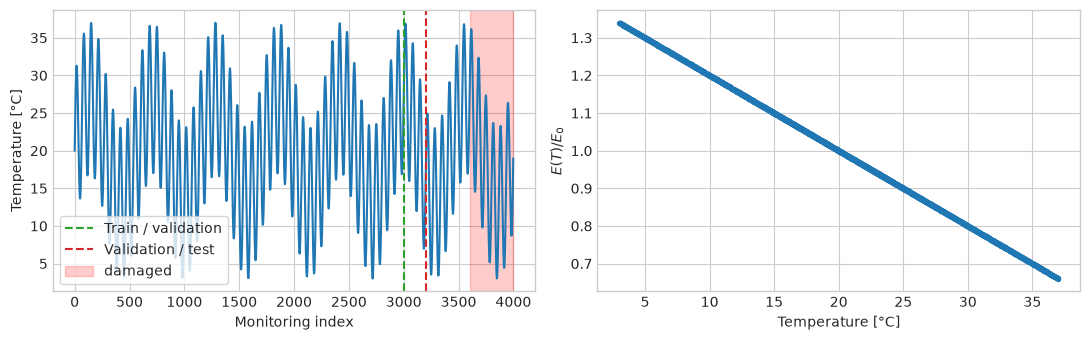

In [13]:
fig, ax = plt.subplots(ncols=2, figsize=(11, 3.5))

ax[0].plot(monitoring_index, temperature_profile)
ax[0].axvline(N_TRAIN, color="tab:green", ls="--", label="Train / validation")
ax[0].axvline(N_TRAIN + N_VAL, color="tab:red", ls="--", label="Validation / test")
ax[0].axvspan(N_SAMPLE-N_TEST_DAMAGE,N_SAMPLE, color="red",alpha=0.2,label='damaged')
ax[0].set(xlabel="Monitoring index", ylabel="Temperature [°C]")
ax[0].legend(frameon=True)

ax[1].scatter(temperature_profile, stiffness_scale(temperature_profile), s=8)
ax[1].set(xlabel="Temperature [°C]", ylabel=r"$E(T)/E_0$")

plt.tight_layout()
plt.show()

The slow horizontal axis represents monitoring time: one point is one experiment. The oscillating profile represents temperature changing throughout the campaign.

The temperature coefficient is deliberately strong so that its effect can be discovered in a short workshop. It is a teaching assumption, not a calibrated material model.

---
---

### Start with one crossing

Before generating thousands of records, we inspect one crossing. This gives physical meaning to the arrays that will later enter the neural network:

```text
moving force → structural response → accelerometer measurements
```

### A quick introduction to DynaResp

[DynaResp](https://github.com/YacineBelHadj/DynaResp) simulates the dynamic response of structural systems.

For each simulation, we define a beam, a load, sensor locations, a time axis, and the conditions of the experiment.

A **case** contains the parameters that change between experiments:

```python
case = {
    "temperature": 20.0,
    "speed": 5.0,
    "load_scale": 1.0,
    "damage_reduction": 0.0,
}
```

DynaResp passes the case to the beam and load builders and then performs the simulation:

```text
case
→ build the beam and load
→ solve the dynamic response
→ record signals and modal properties
```

Providing many cases produces a monitoring campaign containing different environmental, operational, and structural conditions.

> Change one parameter in the case and predict how the acceleration response will change before rerunning the simulation.

In [14]:
beam_properties = {"length": 10, "density": 7850, "area": 0.20, "second_moment": 7.5e-4, "damping_ratio": 0.02, "n_elements": 20, "n_modes": 4}

time_axis = np.arange(0, 4, 0.001)
positions = np.linspace(0, 10, 101)

case = {"temperature": 20.0, "speed": 5.0, "load_scale": 1.0, "damage_reduction": 0.0}

In [17]:
def build_beam(case):
    damage_element = beam_properties["n_elements"] // 2
    damage = {damage_element: case["damage_reduction"]} if case["damage_reduction"] else None

    return dr.Beam(
        **beam_properties,
        young_modulus=210e9 * stiffness_scale(case["temperature"]),
        stiffness_reductions=damage,
    )
def build_two_wheel_load(case):
    return dr.loads.TwoWheelLoad(
        front_load=-400 * case["load_scale"],
        rear_load=-350 * case["load_scale"],
        speed=case["speed"],
        wheel_spacing=1.0,
    )

def build_runner_load(case):
    return dr.loads.RunnerLoad(
        mass=75 * case["load_scale"],
        speed=case["speed"],
        step_frequency=2.2,
        contact_duration=0.2,
    )
sensors = [dr.sensors.Accelerometer(position=x) for x in (1, 5)]

example_record = [
    dr.Record.signal,
    dr.Record.load.values,
    dr.Record.modal_parameter.frequencies_hz,
    dr.Record.modal_parameter.mode_shapes,
    dr.Record.case_parameter,
    dr.Record.time,
    dr.Record.positions,
]

In [18]:
example = dr.generate_dataset(
    cases=[case], system_builder=build_beam, load_builder=build_two_wheel_load,
    sensors=sensors, time=time_axis, positions=positions,
    record=example_record, seed=42,
)

runner_example = dr.generate_dataset(
    cases=[case], system_builder=build_beam, load_builder=build_runner_load,
    sensors=sensors, time=time_axis, positions=positions,
    record=example_record, seed=42,
)

sample = example[0]
runner_sample = runner_example[0]

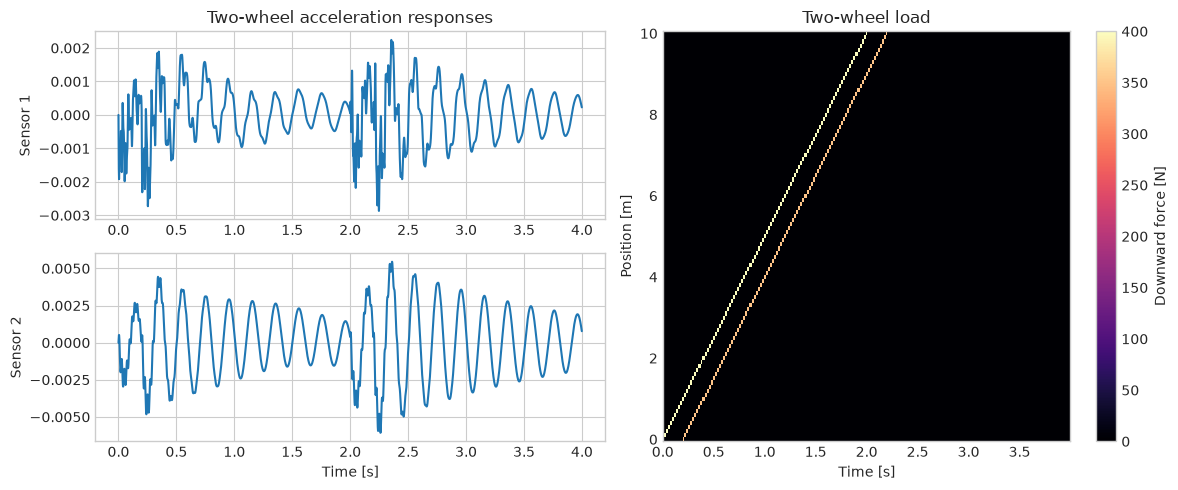

In [33]:
wheel_force = sample.load["values"]

fig, ax = plt.subplot_mosaic([["sensor_1", "load"],
                               ["sensor_2", "load"]],figsize=(12, 5))

for sensor, signal in enumerate(sample.signal):
    axis = ax[f"sensor_{sensor + 1}"]
    axis.plot(sample.time, signal)
    axis.set_ylabel(f"Sensor {sensor + 1}")

ax["sensor_1"].set_title("Two-wheel acceleration responses")
ax["sensor_2"].set_xlabel("Time [s]")

heatmap = ax["load"].pcolormesh(sample.time,sample.positions,-wheel_force,shading="auto",cmap="magma",)

ax["load"].set(title="Two-wheel load",xlabel="Time [s]",ylabel="Position [m]",)

plt.colorbar(heatmap, ax=ax["load"], label="Downward force [N]")
plt.tight_layout()
plt.show()

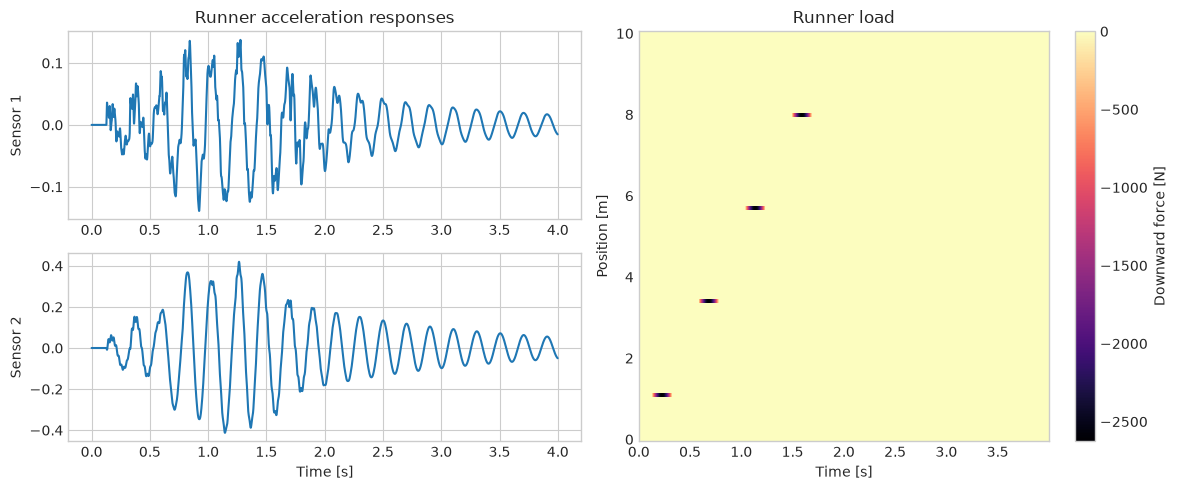

In [35]:
runner_force = runner_sample.load["values"]

fig, ax = plt.subplot_mosaic(
    [["sensor_1", "load"], ["sensor_2", "load"]],
    figsize=(12, 5),
)

for sensor, signal in enumerate(runner_sample.signal):
    axis = ax[f"sensor_{sensor + 1}"]
    axis.plot(runner_sample.time, signal)
    axis.set_ylabel(f"Sensor {sensor + 1}")

ax["sensor_1"].set_title("Runner acceleration responses")
ax["sensor_2"].set_xlabel("Time [s]")

heatmap = ax["load"].pcolormesh(runner_sample.time,runner_sample.positions,-runner_force,shading="auto",cmap="magma",)

ax["load"].set(title="Runner load",xlabel="Time [s]",ylabel="Position [m]",)

plt.colorbar(heatmap, ax=ax["load"], label="Downward force [N]")
plt.tight_layout()
plt.show()

### Modal properties

For a uniform simply supported beam,

$
f_n = \frac{n^2\pi}{2L^2}\sqrt{\frac{EI}{\rho A}}.
$

The expected frequencies are approximately **4.98, 19.90, 44.78, and 79.60 Hz**

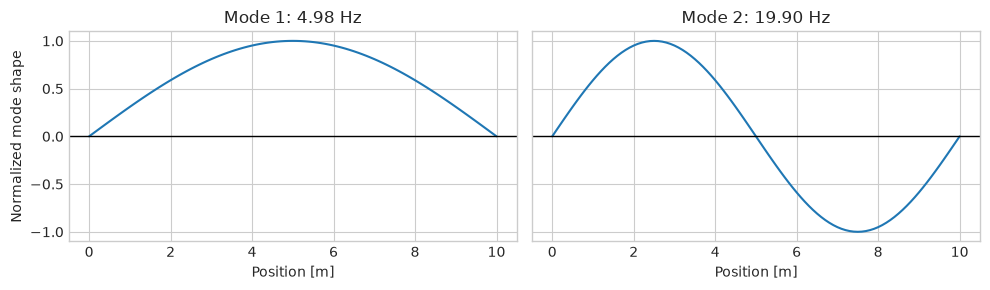

In [28]:
frequencies = sample.modal["frequencies_hz"]
mode_shapes = sample.modal["mode_shapes"]
fig, ax = plt.subplots(ncols=2, figsize=(10, 3), sharey=True)

for mode in range(2):
    shape = mode_shapes[mode] / abs(mode_shapes[mode]).max()
    ax[mode].plot(sample.positions, shape)
    ax[mode].axhline(0, color="black", lw=1)
    ax[mode].set(title=f"Mode {mode + 1}: {frequencies[mode]:.2f} Hz", xlabel="Position [m]")

ax[0].set_ylabel("Normalized mode shape")
plt.tight_layout()
plt.show()

> **Pause:** Which changes the beam's natural frequencies: the applied load, temperature, or local damage? Which changes only the measured response?

### Monitoring campaign

We now repeat the experiment under changing temperature and randomly varying loads. The first 3,600 experiments are healthy; damage appears only in the final 400.

This chronological ordering matters. It mimics monitoring a bridge whose future condition is unknown, rather than randomly mixing damaged observations into training.

The dataset is stored as float32 Zarr data. If it already exists, it is opened instead of regenerated.

In [44]:
rng = np.random.default_rng(42)
cases = []

for index, temperature in enumerate(temperature_profile):
    load_id = rng.integers(3)
    damaged = index >= damage_start

    cases.append({
        "temperature": temperature,
        "load_id": load_id,
        "load_scale": rng.uniform(.8, 1.2),
        "speed": rng.uniform(4, 7) if load_id == 0 else rng.uniform(2, 5) if load_id == 1 else 0.0,
        "load_position": rng.uniform(2, 8),
        "step_frequency": rng.uniform(1.8, 3),
        "harmonic_frequency": rng.uniform(1, 8),
        "phase": rng.uniform(0, 2 * np.pi),
        "damage_state": int(damaged),
        "damage_reduction": .20 if damaged else 0.0,
        "split_id": 0 if index < N_TRAIN else 1 if index < N_TRAIN + N_VAL else 2,
    })

In [45]:
def build_load(case):
    scale = case["load_scale"]

    if case["load_id"] == 0:
        return dr.loads.TwoWheelLoad(
            front_load=-400 * scale, rear_load=-350 * scale,
            speed=case["speed"], wheel_spacing=1,
        )
    if case["load_id"] == 1:
        return dr.loads.RunnerLoad(
            mass=75 * scale, speed=case["speed"],
            step_frequency=case["step_frequency"], contact_duration=.2,
        )
    return dr.loads.Harmonic(
        amplitude=-300 * scale,
        frequency=case["harmonic_frequency"],
        position=case["load_position"],
        phase=case["phase"],
    )

In [46]:
record = [
    dr.Record.signal,
    dr.Record.modal_parameter.frequencies_hz,
    dr.Record.case_parameter,
    dr.Record.time,
    dr.Record.positions,
    dr.Record.metadata.seed,
    dr.Record.metadata.generation,
]

data_path = Path("data/dynaresp_bridge_harmonic_2sensors_float32.zarr")
data_path.parent.mkdir(exist_ok=True)

In [47]:
if data_path.exists():
    dataset = dr.StructuralDataset.open(data_path)
else:
    dataset = dr.generate_dataset(
        cases=cases, system_builder=build_beam, load_builder=build_load,
        sensors=sensors, time=time_axis, positions=positions,
        record=record, storage_dtype=np.float32, output=data_path,
        seed=42, workers=4, progress=True,
    )

print(dataset.summary())

Generating dataset: 100%|██████████| 4000/4000 [12:23<00:00,  5.38sample/s]

dynaresp StructuralDataset
Samples: 4,000
System: Beam
Time samples: 4000
Position samples: 101
Sensors: 2
Signal shape: (2, 4000)
Recorded parameters: damage_reduction, damage_state, harmonic_frequency, load_id, load_position, load_scale, phase, speed, split_id, step_frequency, temperature
Storage: Zarr (lazy)


In [49]:
properties = dataset.properties()
properties["load"] = properties.load_id.map({0: "two-wheel", 1: "runner", 2: "harmonic"})
properties["split"] = properties.split_id.map({0: "train", 1: "validation", 2: "test"})

display(
    properties.groupby(["split", "damage_state"])
    .size().unstack(fill_value=0)
)

damage_state,0,1
split,,
test,400,400
train,3000,0
validation,200,0


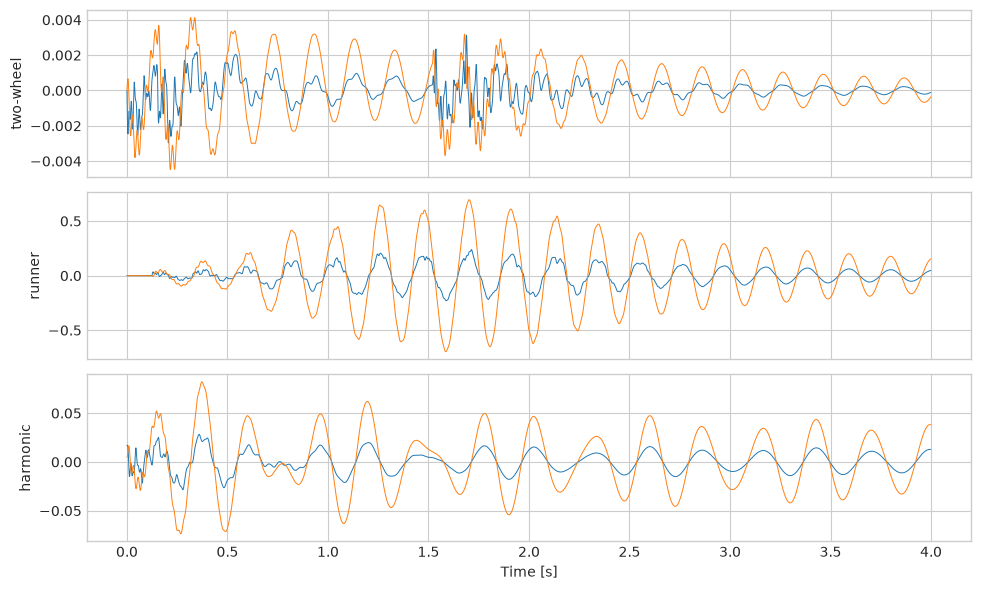

In [50]:
fig, ax = plt.subplots(nrows=3, figsize=(10, 6), sharex=True)

for load_id, axis in enumerate(ax):
    index = properties.query("load_id == @load_id").index[0]
    observation = dataset[index]
    axis.plot(observation.time, observation.signal.T, lw=.7)
    axis.set_ylabel(properties.loc[index, "load"])

ax[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

> we see that each load has its own signature/shape

## 2. First use what structural dynamics already gives us

Before reaching for deep learning, a structural engineer would inspect the natural frequencies. They are compact, physically meaningful features of the beam.

Temperature changes global stiffness and should move all modal frequencies together. Local damage may disturb their healthy relationship. The applied load changes the measured response, but it should not change the beam's natural frequencies.

This creates a useful benchmark: if deep learning cannot improve on, or complement, this simple representation, it may not be necessary.

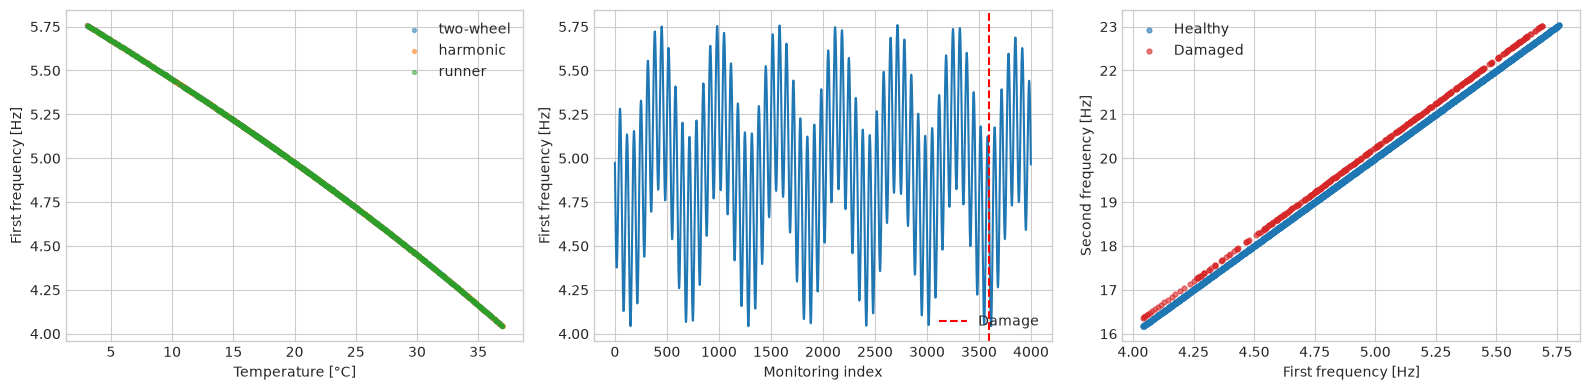

In [51]:
healthy = properties.damage_state.eq(0)
fig, ax = plt.subplots(ncols=3, figsize=(16, 4))

for load in properties.load.unique():
    rows = healthy & properties.load.eq(load)
    ax[0].scatter(properties.loc[rows, "temperature"], properties.loc[rows, "f1_hz"], s=8, alpha=.5, label=load)
ax[0].set(xlabel="Temperature [°C]", ylabel="First frequency [Hz]")
ax[0].legend()

ax[1].plot(properties.index, properties.f1_hz)
ax[1].axvline(damage_start, color="red", ls="--", label="Damage")
ax[1].set(xlabel="Monitoring index", ylabel="First frequency [Hz]")
ax[1].legend()

for state, color, label in [(0, "tab:blue", "Healthy"), (1, "tab:red", "Damaged")]:
    rows = properties.damage_state.eq(state)
    ax[2].scatter(properties.loc[rows, "f1_hz"], properties.loc[rows, "f2_hz"], color=color, s=12, alpha=.6, label=label)
ax[2].set(xlabel="First frequency [Hz]", ylabel="Second frequency [Hz]")
ax[2].legend()
plt.tight_layout()
plt.show()

### Damage detection and load identification

If the resonance frequencies are known, PCA can learn their normal environmental variation and detect changes associated with structural damage.

In real monitoring campaigns, however, resonance frequencies are not directly available. They must first be estimated from measured vibration signals, which may introduce an error of approximately 1–2%. This uncertainty reduces the sensitivity of the detector, but it does not necessarily prevent damage detection when the structural change is sufficiently large.

Deep learning provides a complementary approach. The model ingests the raw acceleration measurements and learns a compact representation without receiving temperature, load, or damage labels.

In this example, the learned representation may reveal the three excitation profiles and describe how the bridge is normally used. It can then help us:

- characterize normal operating conditions;
- estimate how frequently each excitation profile occurs;
- identify unusual or previously unseen uses of the bridge;
- separate operational novelty from possible structural damage.

PCA and deep learning therefore answer different questions. PCA tracks changes in physically meaningful modal properties, while representation learning explores environmental, operational, and structural patterns directly from raw measurements.

## 3. Relying only on raw measurement

Representation learning assumes that a high-dimensional observation \(\mathbf{x}\) is produced by a smaller set of hidden factors \(\mathbf{z}\). Here those factors might contain temperature, load characteristics, and structural condition.

The autoencoder learns

$
\mathbf{x}\xrightarrow{\text{encoder}}\mathbf{z}
\xrightarrow{\text{decoder}}\hat{\mathbf{x}}.
$

It receives no temperature, load, or damage labels. Its only task is to compress each record and reconstruct it.

In [52]:
class BridgeDataModule(L.LightningDataModule):
    def __init__(self, dataset, properties, batch_size=32):
        super().__init__()
        self.dataset = dataset
        self.properties = properties
        self.batch_size = batch_size

    def setup(self, stage=None):
        data = self.dataset.to_torch(inputs="signal", targets="signal")
        split = self.properties.split_id.to_numpy()
        self.train_set = Subset(data, np.where(split == 0)[0])
        self.val_set = Subset(data, np.where(split == 1)[0])
        self.test_set = Subset(data, np.where(split == 2)[0])

    def loader(self, data, shuffle=False):
        return DataLoader(data, batch_size=self.batch_size, shuffle=shuffle)

    def train_dataloader(self): return self.loader(self.train_set, True)
    def val_dataloader(self): return self.loader(self.val_set)
    def test_dataloader(self): return self.loader(self.test_set)

In [57]:
class ConvAutoencoder(L.LightningModule):
    def __init__(self, n_sensors, n_time, latent_size=16, learning_rate=1e-3):
        super().__init__()
        self.save_hyperparameters()

        self.encoder_cnn = nn.Sequential(
            nn.BatchNorm1d(n_sensors),
            nn.Conv1d(n_sensors, 16, 9, 2, 4),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Conv1d(16, 32, 9, 2, 4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, 9, 2, 4),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        compressed_time = n_time // 8
        width = 64 * compressed_time

        self.to_latent = nn.Linear(width, latent_size)
        self.from_latent = nn.Linear(latent_size, width)

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 16, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose1d(16, n_sensors, 4, 2, 1),
        )

    def encode(self, x):
        return self.to_latent(self.encoder_cnn(x).flatten(1))

    def forward(self, x):
        z = self.encode(x)
        hidden = self.from_latent(z)
        hidden = hidden.reshape(len(x), 64, self.hparams.n_time // 8)
        return self.decoder(hidden)

    def step(self, batch, stage):
        x, _ = batch
        loss = F.mse_loss(self(x), x)
        self.log(f"{stage}_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self.step(batch, "train")

    def validation_step(self, batch, batch_idx):
        return self.step(batch, "val")

    def configure_optimizers(self):
        return torch.optim.Adam(
            self.parameters(),
            lr=self.hparams.learning_rate,
        )

In [ ]:
dm = BridgeDataModule(dataset, properties)
logger = CSVLogger("logs", name="bridge_autoencoder")

model = ConvAutoencoder(
    n_sensors=dataset.signal.shape[1],
    n_time=dataset.signal.shape[2],
    latent_size=16,
)

trainer = L.Trainer(max_epochs=50, logger=logger)
trainer.fit(model, datamodule=dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name        | Type       | Params | Mode  | FLOPs
-----------------------------------------------------------
0 | encoder_cnn | Sequential | 23.7 K | train | 0    
1 | to_latent   | Linear     | 512 K  | train | 0    
2 | from_latent | Linear     | 544 K  | train | 0    
3 | decoder     | Sequential | 10.4 K | train | 0    
-----------------------------------------------------------
1.1 M     Trainable params
0         Non-trainable params
1.1 M     Total params
4.360     Total es

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 29:  86%|████████▌ | 81/94 [00:31<00:04,  2.61it/s, v_num=1, val_loss=0.00143, train_loss=0.00111] 

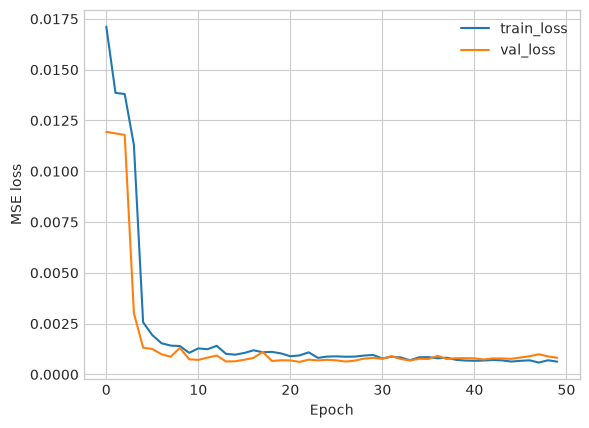

In [55]:
history = pd.read_csv(Path(logger.log_dir) / "metrics.csv")

for name in ("train_loss", "val_loss"):
    curve = history.dropna(subset=[name]).groupby("epoch")[name].last()
    plt.plot(curve, label=name)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()

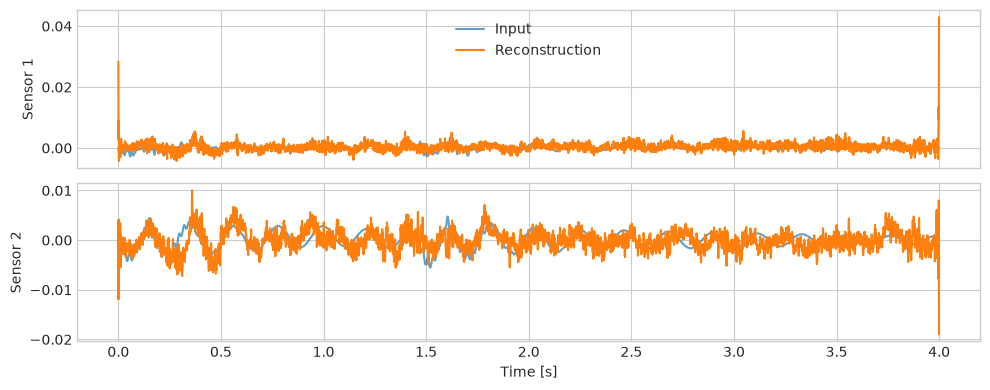

In [56]:
x, _ = next(iter(dm.val_dataloader()))
model.eval()

with torch.no_grad():
    x_hat = model(x.to(model.device)).cpu()

n_sensors = x.shape[1]
fig, ax = plt.subplots(nrows=n_sensors, figsize=(10, 4), sharex=True)

for sensor in range(n_sensors):
    ax[sensor].plot(time_axis, x[0, sensor], alpha=.7, label="Input")
    ax[sensor].plot(time_axis, x_hat[0, sensor], label="Reconstruction")
    ax[sensor].set_ylabel(f"Sensor {sensor + 1}")

ax[0].legend()
ax[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()